# NB04: Agentic GraphRAG (Section C, LangGraph)

## What
This notebook implements Agentic GraphRAG using LangGraph with explicit branching and quality-control nodes.

## Why
A fixed linear pipeline cannot adapt when retrieval quality is poor. Agentic control allows dynamic fallback, graph expansion, and grounding checks.

## When
Use this architecture when retrieval quality varies by query complexity and you need explicit execution control.

## Tradeoffs
- Better robustness and explainability than linear chains.
- More node-level complexity and trace management overhead.
- Additional LLM calls for grading/hallucination checks increase latency and cost.

## Alternatives
- **Why LangGraph**: deterministic state graph, explicit branching, easy node-level instrumentation.
- **Why not plain sequential chains**: weaker control for conditional retries and fallback routing.
- **Why not custom loop only**: possible, but harder to maintain and visualize across evolving workflows.

## Production Considerations
- Bound retries and fallbacks to avoid runaway costs.
- Log node transitions and LLM judge outputs for observability.
- Apply domain-safe web fallback source filtering for biomedical use cases.

In [1]:
# Input: persisted retrieval + graph artifacts and agentic modules.
# Output: runtime initialized for LangGraph execution.
# Logic: load all required state and dependencies once.
# Complexity: O(number_of_chunks + graph size).
from __future__ import annotations

import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent))

from src.agentic_rag import AgentResources, build_agentic_workflow, run_agentic_query, workflow_mermaid
from src.chroma_retriever import get_collection
from src.chunking import load_chunks
from src.config import settings
from src.data_pipeline import load_persisted_records
from src.utils import save_plot, timed_block

records = load_persisted_records()
chunks = load_chunks()
chroma_collection = get_collection("medmentions_chroma_section_a")

with (settings.graph_dir / "entity_graph.pkl").open("rb") as f:
    graph = pickle.load(f)
partition = json.loads((settings.graph_dir / "community_partition.json").read_text(encoding="utf-8"))
summaries = json.loads((settings.graph_dir / "community_summaries.json").read_text(encoding="utf-8"))

print(f"Records: {len(records):,}")
print(f"Chunks: {len(chunks):,}")
print(f"Graph nodes/edges: {graph.number_of_nodes():,}/{graph.number_of_edges():,}")

Records: 4,392
Chunks: 5,098
Graph nodes/edges: 15,454/2,191,052


## Required Workflow

Query
-> Retrieval
-> Retrieval Grader
-> Graph Traversal
-> Context Expansion
-> Answer Generation
-> Hallucination Detection
-> Final Response

If retrieval quality is poor, the workflow branches to web search before graph traversal.

In [2]:
# Input: loaded resources for retrieval and graph context.
# Output: compiled LangGraph application.
# Logic: create explicit node graph and compile to executable app.
# Complexity: O(1) graph construction.
resources = AgentResources(
    chroma_collection=chroma_collection,
    chunks=chunks,
    graph=graph,
    partition=partition,
    summaries=summaries,
)

app = build_agentic_workflow(resources)
print("LangGraph app compiled.")
print("\nWorkflow (Mermaid):\n")
print(workflow_mermaid())

LangGraph app compiled.

Workflow (Mermaid):

flowchart TD
    A[Query] --> B[Retrieval]
    B --> C[Retrieval Grader]
    C -->|Poor| D[Web Search Fallback]
    C -->|Good| E[Graph Traversal]
    D --> E
    E --> F[Context Expansion]
    F --> G[Answer Generation]
    G --> H[Hallucination Detection]
    H -->|Low Grounding, retry once| G
    H --> I[Final Response]


## Node-by-Node Explanation

1. **Retrieval**: fetch top-k candidate chunks.
2. **Retrieval Grader**: score candidate quality with the judge model.
3. **Web Search Fallback**: only used when retrieval score is below threshold.
4. **Graph Traversal**: expand related biomedical concepts.
5. **Context Expansion**: combine vector, graph, and optional web context.
6. **Answer Generation**: generate grounded response with citations.
7. **Hallucination Detection**: assess grounding quality and optionally retry.
8. **Final Response**: deliver final answer and trace.

## Step 1: Visualize the Workflow Graph

We store the Mermaid diagram as a markdown artifact used by README and reports.

In [3]:
# Input: workflow Mermaid text.
# Output: persisted Mermaid markdown file.
# Logic: save graph visualization source for docs and review workflows.
# Complexity: O(1).
workflow_md = "```mermaid\n" + workflow_mermaid() + "\n```\n"
workflow_path = settings.outputs_dir / "figures" / "nb04_agent_workflow_mermaid.md"
workflow_path.parent.mkdir(parents=True, exist_ok=True)
workflow_path.write_text(workflow_md, encoding="utf-8")
print("Saved workflow diagram markdown:", workflow_path)

Saved workflow diagram markdown: /home/ahmad/AI/Medical-Research-GraphRAG/outputs/figures/nb04_agent_workflow_mermaid.md


## Step 2: Run Representative Queries

We run biomedical queries to inspect:
- branch route decisions
- node trace order
- hallucination score behavior
- final answer quality

In [4]:
# Input: representative biomedical queries.
# Output: full final states from LangGraph workflow.
# Logic: invoke compiled app for each query and collect key fields.
# Complexity: O(number_of_queries * workflow_cost).
demo_queries = [
    "What does this corpus report about diabetes and insulin resistance?",
]

demo_states: list[dict] = []
for query in demo_queries:
    with timed_block(f"Agentic query: {query[:60]}"):
        demo_states.append(run_agentic_query(app, query))

for idx, state in enumerate(demo_states, start=1):
    print(f"\n==== Agentic Demo {idx} ====")
    print("Query:", state.get("query", ""))
    print("Route:", state.get("route", ""))
    print("Retrieval score:", state.get("retrieval_score", 0.0))
    print("Hallucination score:", state.get("hallucination_score", 0.0))
    print("Trace:", " -> ".join(state.get("trace", [])))
    print("Answer preview:", state.get("final_answer", "")[:420], "...")

2026-06-22 10:03:24 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:03:24 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:03:24 | INFO | embed_texts completed in 0.20s


2026-06-22 10:03:49 | INFO | Agentic query: What does this corpus report about diabetes and insulin resi completed in 25.64s

==== Agentic Demo 1 ====
Query: What does this corpus report about diabetes and insulin resistance?
Route: graph_traversal
Retrieval score: 0.85
Hallucination score: 0.95
Trace: retrieval -> retrieval_grader -> graph_traversal -> context_expansion -> answer_generation -> hallucination_detection -> final_response
Answer preview: The corpus indicates that fasting triglycerides are a significant predictor of incident diabetes and insulin resistance, particularly among First Nations populations in Canada. Specifically:

1. Participants with higher triglyceride levels (≥2.11 mmol/l) had a 4.0-times greater risk of developing diabetes compared to those with lower levels (p=0.03) [1].  
2. Fasting triglycerides were identified as an important pred ...


## Step 3: Branch Analysis (Fallback vs Direct Path)

This section quantifies which queries used web fallback and why.

In [5]:
# Input: collected demo states.
# Output: route summary table.
# Logic: aggregate route, scores, and retry behavior by query.
# Complexity: O(number_of_queries).
route_rows = []
for state in demo_states:
    route_rows.append(
        {
            "query": state.get("query", ""),
            "route": state.get("route", ""),
            "retrieval_score": float(state.get("retrieval_score", 0.0)),
            "hallucination_score": float(state.get("hallucination_score", 0.0)),
            "retries": int(state.get("retries", 0)),
            "trace": " -> ".join(state.get("trace", [])),
        }
    )

route_df = pd.DataFrame(route_rows)
route_df

,query,route,retrieval_score,hallucination_score,retries,trace
0,What does this corpus report about diabetes an...,graph_traversal,0.85,0.95,0,retrieval -> retrieval_grader -> graph_travers...


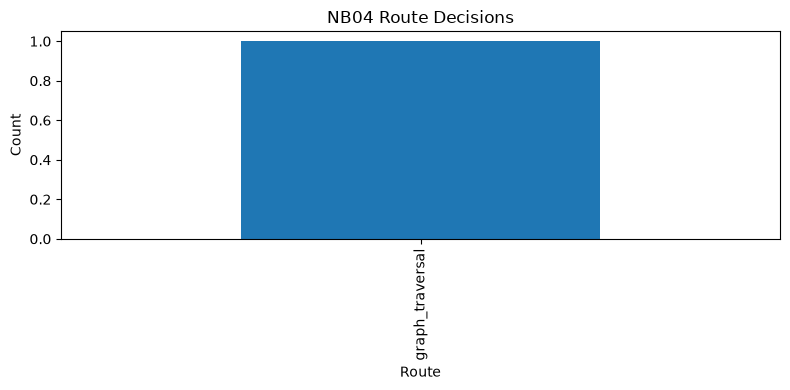

In [6]:
# Input: route summary dataframe.
# Output: saved branch-analysis chart.
# Logic: plot route counts to visualize fallback frequency.
# Complexity: O(number_of_queries).
plt.figure(figsize=(8, 4))
route_df["route"].value_counts().plot(kind="bar", color="#1f77b4", title="NB04 Route Decisions")
plt.xlabel("Route")
plt.ylabel("Count")
save_plot(settings.figures_dir / "nb04_route_decisions.png")
plt.show()

## Step 4: Persist Agentic Artifacts

### Historical outputs
Existing outputs from earlier runs are retained for comparison.

### Pending outputs
Additional execution-time screenshots/metrics can be populated in the later validation run.

In [7]:
# Input: demo states, route summary, and workflow diagram.
# Output: persisted tables and JSON artifacts for README integration.
# Logic: save machine-readable run traces and human-readable tables.
# Complexity: O(number_of_queries).
route_df.to_csv(settings.tables_dir / "nb04_agentic_route_summary.csv", index=False)

agent_payload = {
    "workflow_mermaid": workflow_mermaid(),
    "demo_queries": demo_queries,
    "demo_states": demo_states,
    "notes": {
        "historical_outputs_kept": True,
        "execution_phase_required_for_validation": True,
    },
}

(settings.metrics_dir / "nb04_agentic_demo.json").write_text(
    json.dumps(agent_payload, indent=2, ensure_ascii=True),
    encoding="utf-8",
)

print("Saved NB04 agentic artifacts.")

Saved NB04 agentic artifacts.
